### **Projet: Analysez des images médicales avec des méthodes semi-supervisées**

 **Contexte**  
- 1500 images IRM cérébrales (≈1400 non labellisées, ≈100 labellisées)
- 2 classes labellisées : `normal` vs `cancer`

**Objectifs**
1) Explorer les images + contrôle qualité (doublons / quasi-doublons)
2) Extraire des embeddings (features) via un modèle pré-entraîné (ResNet18)
3) Clustering (KMeans + GMM), évaluation via ARI, création de pseudo-labels
4) Semi-supervisé : comparer
- Supervisé-only (train sur labels experts)
- "Faiblements" labellisées → "Fortement" labellisées (pré-entraînement sur pseudo-labels puis fine-tuning sur labels experts)

**Important**
- On garde **séparé** : (A) labels experts vs (B) pseudo-labels.
- On évite la fuite train/test : doublons exacts + quasi-doublons (group split).

## Étape 1 — Import & exploration + contrôle qualité (doublons / quasi-doublons) + split anti-fuite

**Objectif :**
- Charger les chemins des images (avec labels et sans label)
- Explorer rapidement le dataset (taille, mode couleur, exemples)
- Détecter les doublons exacts (hash MD5) et les supprimer
- Détecter des quasi-doublons (hash perceptuel dHash) et faire un split "groupé" pour limiter la fuite train/val/test


In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from pathlib import Path
import random

In [107]:
DATA_DIR = Path("../data/raw/")
LABELED_DIR = DATA_DIR / "avec_labels"
UNLABELED_DIR = DATA_DIR / "sans_label"

print("LABELED_DIR:", LABELED_DIR.resolve())
print("UNLABELED_DIR:", UNLABELED_DIR.resolve())


LABELED_DIR: /Users/kseniadautel/projet_image/data/raw/avec_labels
UNLABELED_DIR: /Users/kseniadautel/projet_image/data/raw/sans_label


### 1.1 Construire les DataFrames (paths + labels) 
Dataset attendu :
- `df_labeled`: paths+labels
- `df_unlabeled`: paths

In [108]:
# Images non labellisées
unlabeled_pathes = sorted(UNLABELED_DIR.glob("*.jpg"))
df_unlabeled = pd.DataFrame({
    "path": [str(p) for p in unlabeled_pathes]
})
print(f"Nombre images sans labels: {len(df_unlabeled)}")
df_unlabeled.head()


Nombre images sans labels: 1406


,path
0,../data/raw/sans_label/001b158a-7af8-451e-bf31...
1,../data/raw/sans_label/00366e8d-5520-4d3c-a70b...
2,../data/raw/sans_label/00455a62-f79f-4072-9a23...
3,../data/raw/sans_label/004ce5f5-ca6b-490f-9b2f...
4,../data/raw/sans_label/005d9a37-8894-4eb5-8367...


In [4]:
# Images labellisées
class_names = ["cancer", "normal"]

labeled_rows = []

for cls in class_names:
    cls_path = LABELED_DIR / cls
    paths = sorted(cls_path.glob("*.jpg"))
    print(f"Nombre d'images dans la classe '{cls}': {len(paths)}")

    for p in paths:
        labeled_rows.append ({
            "path": str(p),
            "label_str": cls,
            "label": 1 if cls =="cancer" else 0
        })
df_labeled = pd.DataFrame(labeled_rows)
print(f"Nombre total d'images labellisées: {len(df_labeled)}")
print(df_labeled["label_str"].value_counts().to_dict())
df_labeled.head()



Nombre d'images dans la classe 'cancer': 50
Nombre d'images dans la classe 'normal': 50
Nombre total d'images labellisées: 100
{'cancer': 50, 'normal': 50}


,path,label_str,label
0,../data/raw/avec_labels/cancer/05340cd4-3bb2-4...,cancer,1
1,../data/raw/avec_labels/cancer/0c6f3641-60d9-4...,cancer,1
2,../data/raw/avec_labels/cancer/0f718241-8f63-4...,cancer,1
3,../data/raw/avec_labels/cancer/11a7a426-4806-4...,cancer,1
4,../data/raw/avec_labels/cancer/1c043dbb-4623-4...,cancer,1


## 1.2 Exploration rapide (qualité, tailles, mode couleur)
Objectif: vérifier que le dataset est exploitable
- `mode` : RGB / L
- `size` : résolution
- fichiers cassés

In [30]:
# Exploration visuelle des données, échantillonnage 300 images aléatoires

def inspect_random_images(paths, n_sample=300, seed = 42):
    random.seed(seed)
    sampled_paths = random.sample(paths, k=min(n_sample, len(paths)))

    sizes = []
    modes = []
    broken = 0

    for p in sampled_paths:
        try:
            im = Image.open(p)
            sizes.append(im.size)
            modes.append(im.mode)
        except Exception:
            broken += 1

    sizes = np.array(sizes) if len(sizes) > 0 else np.empty((0,2))

    return {
        "n_sampled": len(sampled_paths),
        "n_broken_files": broken,
        "modes": sorted(set(modes)),
        "sizes": sizes
    }
labeled_stats = inspect_random_images(df_labeled['path'].tolist(), n_sample=100)
unlabeled_stats = inspect_random_images(df_unlabeled['path'].tolist(), n_sample=300)

print("Labeled images stats:", labeled_stats)
print("Unlabeled images stats:", unlabeled_stats)


Labeled images stats: {'n_sampled': 99, 'n_broken_files': 0, 'modes': ['RGB'], 'sizes': array([[512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],
       [512, 512],


In [31]:
# Affichage des exemples d'images (par classe et sans label)

def show_grid_of_images(paths, title, n=9, seed=42):
    random.seed(seed)
    sampled_paths = random.sample(paths, k=min(n, len(paths)))
    
    fig, axes = plt.subplots(3, 3, figsize=(8,8))
    axes = axes.ravel()

    for ax, p in zip(axes, sampled_paths):
        im = Image.open(p)
        ax.imshow(im, cmap='gray' if im.mode == 'L' else None)
        ax.axis('off')
        ax.set_title(Path(p).name, fontsize=8)

    for ax in axes[len(sampled_paths):]:
        ax.axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

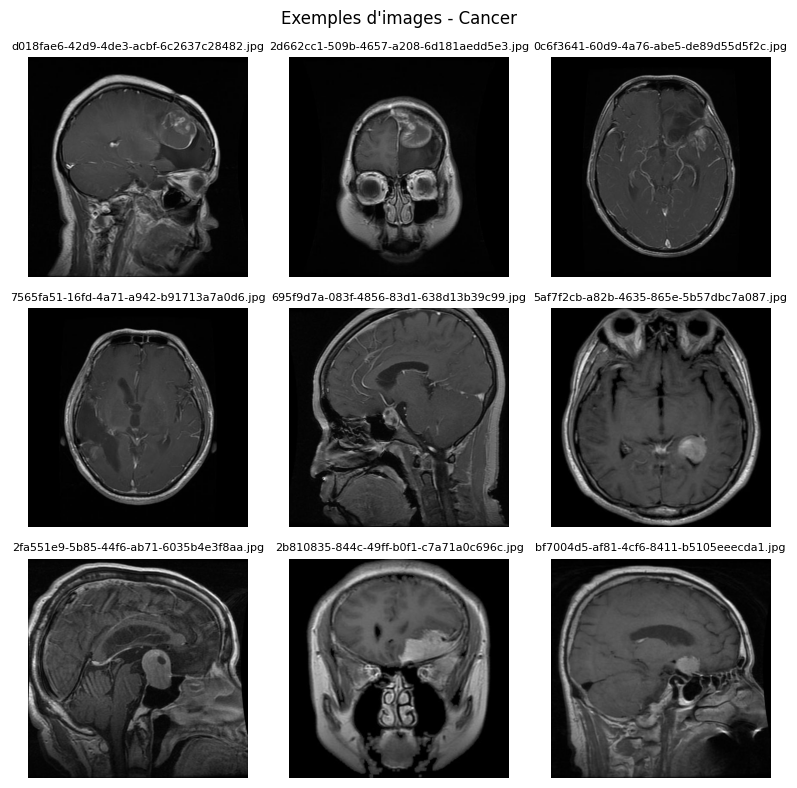

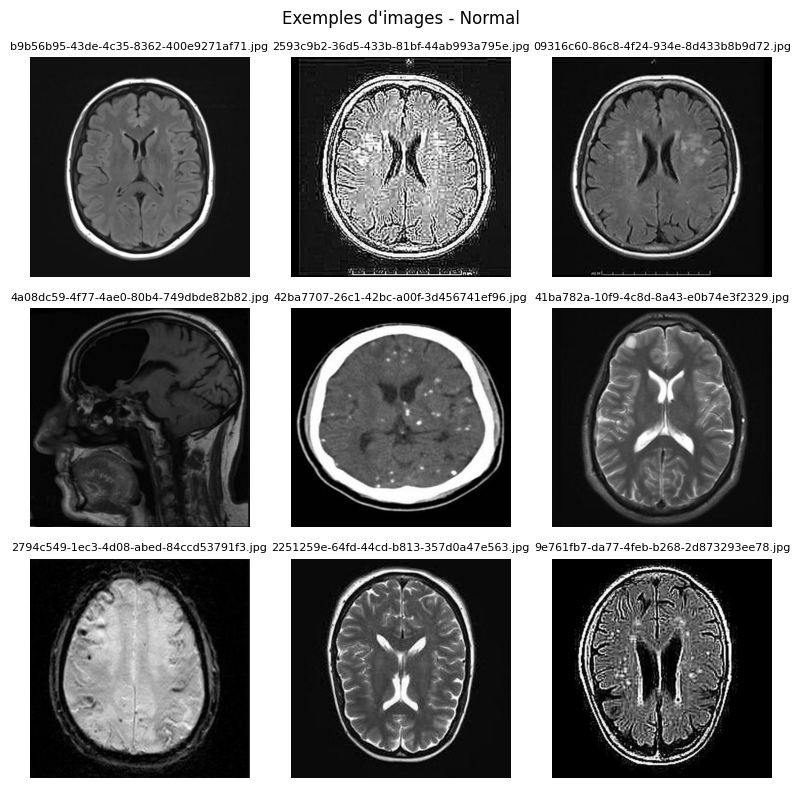

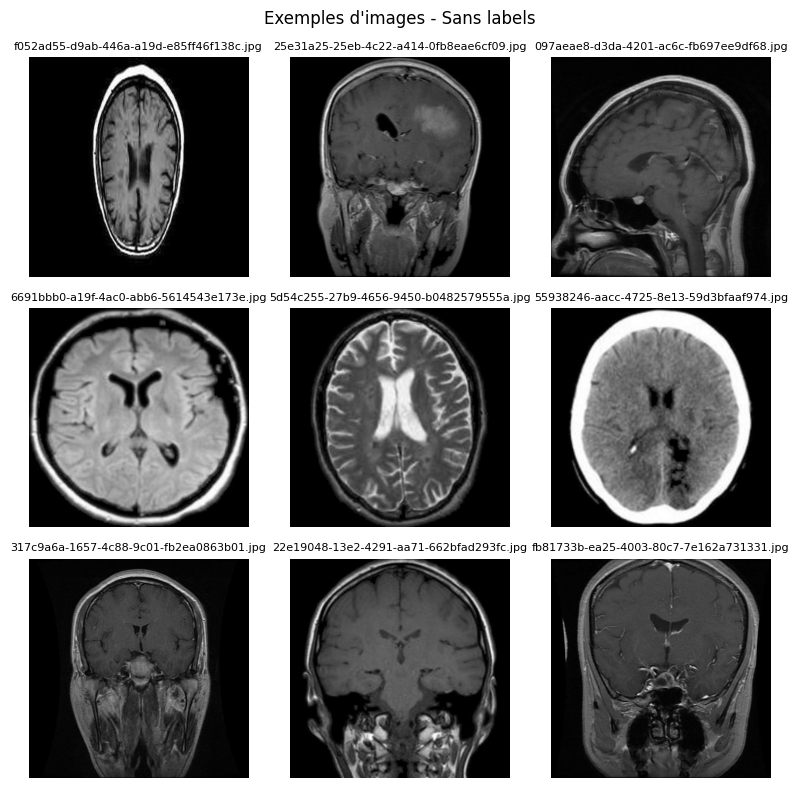

In [32]:
cancer_paths = df_labeled[df_labeled['label_str'] == 'cancer']['path'].tolist()
normal_paths = df_labeled[df_labeled['label_str'] == 'normal']['path'].tolist()

show_grid_of_images(cancer_paths, title="Exemples d'images - Cancer")
show_grid_of_images(normal_paths, title="Exemples d'images - Normal")
show_grid_of_images(df_unlabeled['path'].tolist(), title="Exemples d'images - Sans labels")


### 1.3 Contrôle qualité : doublons exacts (MD5) + suppression

- Si la même image existe plusieurs fois, elle peut se retrouver en train et en test
- Les métriques peuvent alors être artificiellement trop élevées (fuite de données)

**Méthode :**
- Calcul du hash MD5 du fichier (doublon exact = même MD5)
- Suppression des doublons exacts

In [33]:
import hashlib
def compute_image_hash(path, chunk_size=1024*1024):
    hasher = hashlib.md5()
    with open(path, 'rb') as f:
        while True :
            data = f.read(chunk_size)
            if not data:
                break
            hasher.update(data)
    return hasher.hexdigest()



In [34]:
# Détection des doublons dans le dataset labellisé
df_labeled_qc = df_labeled.copy()
df_labeled_qc['hash'] = df_labeled_qc['path'].apply(compute_image_hash)

dup_hashes = df_labeled_qc[df_labeled_qc.duplicated(subset=["hash"], keep=False)].sort_values(by="hash")
print(f"Nombre de groupes de doublons trouvés:", len(dup_hashes['hash']))
 

Nombre de groupes de doublons trouvés: 0


In [35]:
# si doublons
if len(dup_hashes) > 0:
    for dup_hashes, group in dup_hashes.groupby("hash"):
        print(f"Duplicate group for hash {dup_hashes}:",len(group))
        print(group[["path", "label_str"]].to_string(index=False))
else:
    print("Aucun doublon trouvé")

Aucun doublon trouvé


In [36]:
# Suppression des doublons en gardant le premier
before = len(df_labeled_qc)
df_labeled_qc = df_labeled_qc.drop_duplicates(subset=["hash"], keep="first").reset_index(drop=True)
after = len(df_labeled_qc)
print(f"Après suppression doublons exacts: {after} (supprimés: {before-after})")


Après suppression doublons exacts: 99 (supprimés: 0)


In [37]:
# Mise à jour du dataframe initial
df_labeled = df_labeled_qc.drop(columns=["hash"]).copy()
print(f"Dataframe labellisé nettoyé, nombre d'images: {len(df_labeled)}")
print(df_labeled["label_str"].value_counts().to_dict())

Dataframe labellisé nettoyé, nombre d'images: 99
{'cancer': 50, 'normal': 49}


### 1.4 Contrôle qualité : quasi-doublons
**Objectif :**
- Détecter des images **très proches** (même image avec légère variation, compression, contraste…)

Méthode :
- dHash (hash perceptuel) + distance de Hamming
- On crée ensuite un `group_id` qui regroupe les images proches
- On fait un split **groupé** pour éviter que des images similaires soient réparties entre train/test


In [38]:
# Quasi-identical images detection
from PIL import Image

def compute_image_difference(path, hash_size=8):
    img = Image.open(path).convert("L").resize((hash_size + 1, hash_size))
    pixels = np.array(img)
    diff = pixels[:, 1:] > pixels[:, :-1]
    bits = diff.flatten()
    h = 0
    for bit in bits:
        h = (h << 1) | int(bit)
    return int(h)

def hamming(a, b):
    x = int(a) ^ int(b)
    return bin(x).count("1")


In [39]:
df_labeled_qd = df_labeled.copy()
df_labeled_qd['img_hash'] = df_labeled_qd['path'].apply(compute_image_difference)

In [40]:
# compaer toutes les paires d'images
threshold = 5
paths = df_labeled_qd['path'].tolist()
labels = df_labeled_qd['label_str'].tolist()
hashes = df_labeled_qd['img_hash'].tolist()

pairs = []
n = len(paths)
for i in range(n):
    for j in range(i + 1, n):
        dist = hamming(hashes[i], hashes[j])
        if dist <= threshold:
            pairs.append((i, j, dist))

# afficher les paires similaires
pairs = sorted(pairs, key=lambda x: x[2])
print(f"Number of quasi-identical image pairs (distance <= {threshold}):", len(pairs))
print("Examples of quasi-identical image pairs:", pairs[:5])  # afficher les 5 premières paires

Number of quasi-identical image pairs (distance <= 5): 11
Examples of quasi-identical image pairs: [(52, 82, 0), (52, 74, 2), (74, 82, 2), (51, 78, 4), (52, 95, 4)]


### Construire un `group_id` (Union-Find) à partir des paires quasi-identiques
Cela permet de regrouper automatiquement :
- toutes les images très similaires ensemble
- et de faire ensuite un split **sans fuite** (un groupe ne peut pas être à la fois en train et en test)


In [41]:
# Union-Fined (Disjoint Set Union) des doublons exacts et quasi-identiques
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    rootA = find(a)
    rootB = find(b)
    if rootA != rootB:
        parent[rootB] = rootA

In [42]:
for i,j, dist in pairs:
    union(i, j)

# création des groupes
groups_raw = [find(i) for i in range(n)]
df_labeled_qd['group_id'] = groups_raw

print(f"Nombre de groupes après union des quasi-identiques:", df_labeled_qd['group_id'].nunique())
print("Tailles des plus grands groupes:", df_labeled_qd['group_id'].value_counts().head(10))


# Mise à jour df_labeled avec les groupes
df_labeled = df_labeled_qd.copy()

Nombre de groupes après union des quasi-identiques: 92
Tailles des plus grands groupes: group_id
52    4
56    4
51    2
0     1
59    1
67    1
66    1
65    1
64    1
63    1
Name: count, dtype: int64


In [127]:
df_labeled = df_labeled.drop(columns=["img_hash"]).copy()

### Anti-fite SSL: supprimer overlap MD5 entre labeles et unlabeled.

Pour evité qu'une image test pourrait être identique dans `sans_label`

In [128]:
DO_MD5_OVERLAP_CKECK = True

if DO_MD5_OVERLAP_CKECK:
    # Vérification des chevauchements entre les ensembles labellisés et non labellisés
    df_unlabeled_qc = df_unlabeled.copy()
    df_unlabeled_qc['md5'] = df_unlabeled_qc['path'].apply(compute_image_hash)

    df_labeled_md5 = df_labeled.copy()
    df_labeled_md5['md5'] = df_labeled_md5['path'].apply(compute_image_hash)

    overlap = set(df_unlabeled_qc['md5']) & set(df_labeled_md5['md5'])
    print(f"Nombre d'images en chevauchement entre labellisé et non labellisé:", len(overlap))

    # retirer les images en chevauchement du dataset non labellisé
    df_unlabeled = df_unlabeled_qc[~df_unlabeled_qc['md5'].isin(overlap)][['path']].reset_index(drop=True)
    print(f"Dataset non labellisé après retrait des chevauchements, nombre d'images:", len(df_unlabeled))
    

Nombre d'images en chevauchement entre labellisé et non labellisé: 31
Dataset non labellisé après retrait des chevauchements, nombre d'images: 1374


### Outliers (luminosité)

In [129]:
def image_brightness(path):
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.float32)
    return float(arr.mean())


In [130]:
df_labeled['brightness'] = df_labeled['path'].apply(image_brightness)
print("Brightness stats (labeled):", df_labeled['brightness'].describe())

Brightness stats (labeled): count     99.000000
mean      53.926531
std       21.474068
min       19.505821
25%       39.852684
50%       51.691601
75%       62.567295
max      115.188713
Name: brightness, dtype: float64


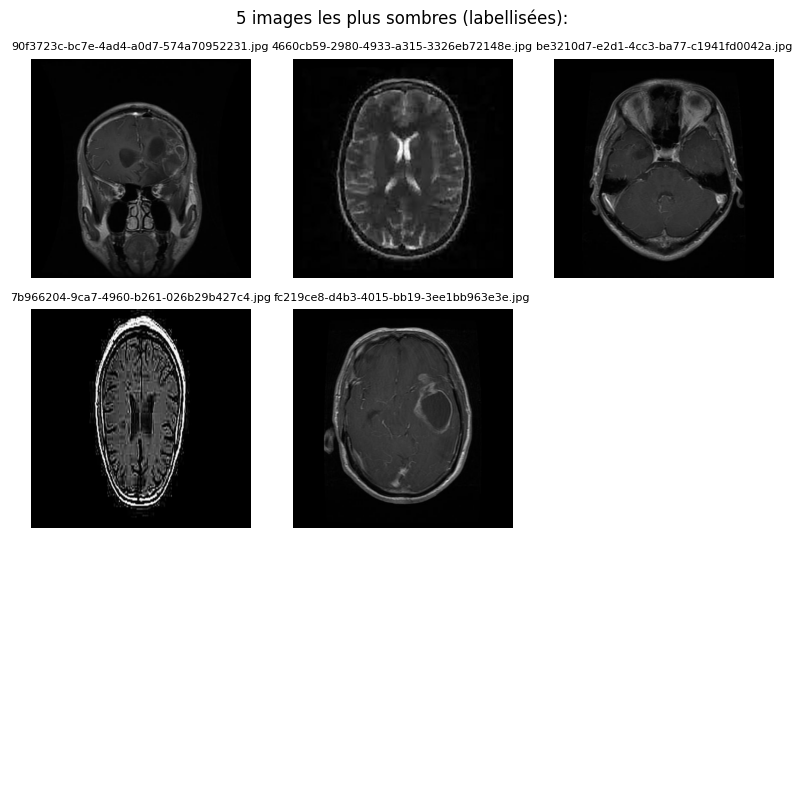

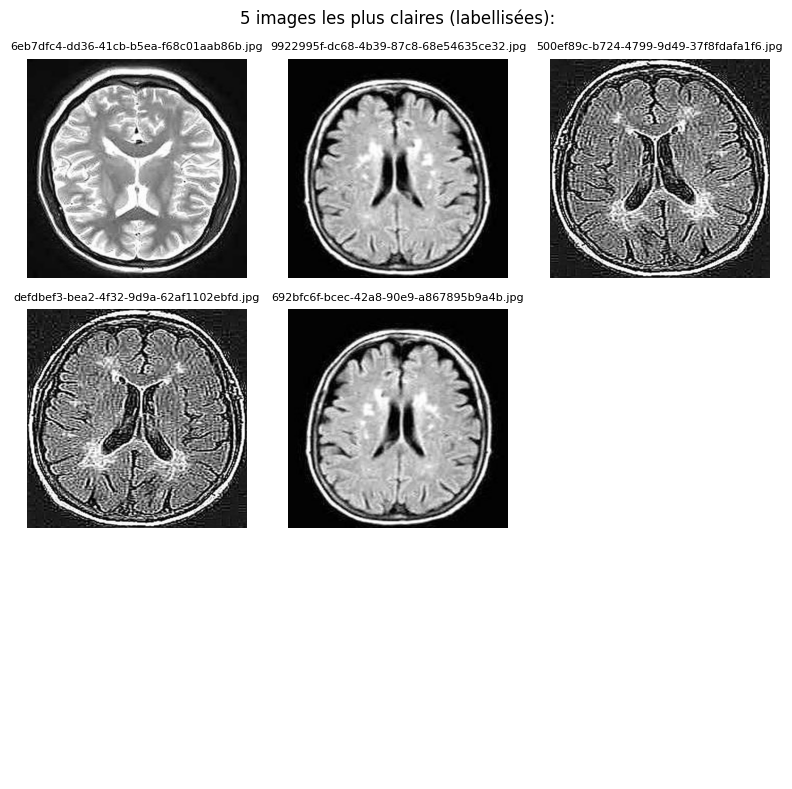

In [132]:
darkest = df_labeled.sort_values(by="brightness").head(5)['path'].tolist()
show_grid_of_images(darkest,"5 images les plus sombres (labellisées):", n=6)

brightest = df_labeled.sort_values(by="brightness", ascending=False).head(5)['path'].tolist()
show_grid_of_images(brightest, "5 images les plus claires (labellisées):", n=6)


### 1.5 Split train/test anti-fuite (GroupShuffleSplit)
On split les **images labellisées** en 2 ensembles :
- Test : 20%
- Train/Val groupé : 80% 

In [133]:
# Splitting train/val/test en évitant les doublons dans les splits
from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df_labeled, df_labeled['label'], groups=df_labeled['group_id']))

df_train_val = df_labeled.iloc[train_val_idx].copy()
df_test = df_labeled.iloc[test_idx].copy()

print(f"Train/Val set size:", len(df_train_val), df_train_val["label_str"].value_counts().to_dict())
print(f"Test set size:", len(df_test), df_test["label_str"].value_counts().to_dict())

Train/Val set size: 80 {'normal': 43, 'cancer': 37}
Test set size: 19 {'cancer': 13, 'normal': 6}


In [134]:
# Recherche splitting train/val groupé avec une validation stratifiée

def make_train_val_split(df_train_val, val_size=0.15, min_per_class=3, max_tries=200):
    """ Cherche une séparation train/val où chaque classe a au moins `min_per_class` exemples dans le set de validation."""
    for seed in range(max_tries):
        gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
        train_idx, val_idx = next(gss_val.split(df_train_val, df_train_val['label'], groups=df_train_val['group_id']))
        
        df_train = df_train_val.iloc[train_idx].copy()
        df_val = df_train_val.iloc[val_idx].copy()

        vc = df_val['label_str'].value_counts().to_dict()
        if vc.get('normal', 0) >= min_per_class and vc.get('cancer', 0) >= min_per_class:
            print(f"Successful train/val split with seed {seed}")
            return df_train, df_val, seed
        
    raise ValueError("Failed to create a valid train/val split")




In [135]:
df_train, df_val, used_seed = make_train_val_split(df_train_val, val_size=0.15, min_per_class=3)
print(f"Seed choisie pour le split train/val: {used_seed}")
print(f"Train set size:", len(df_train), df_train["label_str"].value_counts().to_dict())
print(f"Val set size:", len(df_val), df_val["label_str"].value_counts().to_dict())
print(f"Test set size:", len(df_test), df_test["label_str"].value_counts().to_dict())

Successful train/val split with seed 0
Seed choisie pour le split train/val: 0
Train set size: 66 {'normal': 34, 'cancer': 32}
Val set size: 14 {'normal': 9, 'cancer': 5}
Test set size: 19 {'cancer': 13, 'normal': 6}


### Conclusion: 

Le dataset contient 100 images annotées (50 cancer, 50 normal), et 1406 images non annotées. Les images sont toutes au format RGB et la résolution observée est 512×512. Les doublons sont suprimées. Pour les quasi-doublons j'ai crée un group `group_id` via Union-Find. Split anti-fuite a été realisé:
Le test fixe est obtenu via un split groupé (anti-fuite) ; sa distribution est légèrement déséquilibrée (13 cancer / 6 normal) en raison de la contrainte de regroupement.
Le split train/validation a été réalisé avec contrainte de groupe (anti-fuite). Le train est quasi équilibré (34 normal / 32 cancer) et la validation est utilisable (9/5). Le test fixe est légèrement déséquilibré (13 cancer / 6 normal) du fait de la contrainte de regroupement et de la faible taille du dataset ; nous privilégions donc les métriques métier (Recall cancer, F1 et matrice de confusion)

## Etape 2 Prétraitement les images et extraction de feautures (embeddings) (ResNet18 -> 512D)

In [46]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

In [48]:
print ("torch veersion:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

torch veersion: 2.8.0
MPS available: True


In [49]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Device:", device)

Device: mps


In [136]:
# Preprocessing et création de Dataset (resize, normalization)
img_size = 224

preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

Resize: changement de dimansion 512x512 -> 224x224 (standard pour ResNet)

ToTensor: convertir image en tenseur PyTorch ( PIL -> Tensor [0,1], shape (C,H,W))

Normalize: normalisation ImageNet, en mettent les pixels dans le meme "échelle" que l'entrainement du modèle

In [137]:
# Creation un DataSet
class ImagePathDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = list(paths)
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, str(path)
        

In [138]:
# DataLoaders (batching)
from torch.utils.data import DataLoader

batch_size = 64

labeled_loader = DataLoader(
    ImagePathDataset (df_labeled["path"].tolist(), transform=preprocess),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

unlabeled_loader = DataLoader(
    ImagePathDataset(df_unlabeled["path"].tolist(), transform=preprocess),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [139]:
# Exemple de batch
imgs, paths = next(iter(labeled_loader))
print("Batch shape:", imgs.shape)
print("Example path type:",paths [0])

Batch shape: torch.Size([64, 3, 224, 224])
Example path type: ../data/raw/avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg


`batch_size` nombre d’images traitées “d’un coup”. Plus grand = plus rapide

`shuffle=False` on garde l’ordre pour associer correctement `path → embedding``


### Chargement ResNet pré-entrainé comme extracteur de feautures
Transformation d'image en un vecteur (embedding) de taille fixe (ResNet: 512)
Je remplace fc par Identity -> 512D

In [140]:
import torch
from torch import nn
from torchvision import models

#ResNet pré-entrainé
weights = models.ResNet18_Weights.DEFAULT  
model = models.resnet18(weights=weights)

# on enlève la dernière couche de classification 'head', sortie = embedding
model.fc = nn.Identity()

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [141]:
# Fonction d'extraction des embeddings (batch par batch)
@torch.no_grad()
def extract_embeddings(loader, model, device):
    all_feats = []
    all_paths = []

    for imgs, paths in loader:
        imgs = imgs.to(device)

        feats = model(imgs)              
        feats = feats.detach().cpu().numpy()

        all_feats.append(feats)
        all_paths.extend(paths)

    X = np.vstack(all_feats)            
    return all_paths, X


In [142]:
# Extraction features
l_paths, X_labeled = extract_embeddings(labeled_loader, model, device)
u_paths, X_unlabeled = extract_embeddings(unlabeled_loader, model, device)

print("X_labeled  :", X_labeled.shape)
print("X_unlabeled:", X_unlabeled.shape)

X_labeled  : (99, 512)
X_unlabeled: (1374, 512)


In [143]:
# Check features statistics
def inspect_random_images(name, X):
    X = np.array(X)
    print(f"\n--- {name} ---")
    print("Shape:", X.shape, "dtype:", X.dtype)
    print("Min:", X.min(), "Max:", X.max())
    print("Mean:", X.mean(), "Std:", X.std())
    print("Median:", np.median(X))


In [144]:
inspect_random_images("Labeled", X_labeled)
inspect_random_images("Unlabeled", X_unlabeled)


--- Labeled ---
Shape: (99, 512) dtype: float32
Min: 0.0 Max: 8.341928
Mean: 0.8179663 Std: 0.84492743
Median: 0.55784166

--- Unlabeled ---
Shape: (1374, 512) dtype: float32
Min: 0.0 Max: 9.619476
Mean: 0.8586346 Std: 0.8601708
Median: 0.60234964


In [145]:
# Affichage un embedding 10 premiers valeurs

print ("Chemins des 10 premières images labellisées", l_paths[0])
y_map = df_labeled.set_index('path')['label']
print ("Labels expert", y_map.loc[l_paths[0]])
print ("Embedding des 10 premières images labellisées", X_labeled[0, :10])


Chemins des 10 premières images labellisées ../data/raw/avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
Labels expert 1
Embedding des 10 premières images labellisées [0.22368193 0.71013516 1.4812564  0.45943037 0.69208556 0.1853633
 2.0596275  0.42361376 0.16368644 1.0266839 ]


In [146]:
# Sauvegarde les features labeled/unlabeled séparement

FEATURES_DIR = Path ("../data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

np.save(FEATURES_DIR / "X_labeled.npy", X_labeled)
np.save(FEATURES_DIR / "X_unlabeled.npy", X_unlabeled)

In [147]:
# index des features sauvegardés y_true = labels expert alignés avec l'ordre des features l_paths
y_true = y_map.loc[l_paths].values

pd.DataFrame({
    "path": l_paths,
    "label": y_true
}).to_csv(FEATURES_DIR / "labeled_index.csv", index=False)

pd.DataFrame({"path": u_paths}).to_csv(FEATURES_DIR / "unlabeled_index.csv", index=False)

print("Saved in:", FEATURES_DIR.resolve())

Saved in: /Users/kseniadautel/projet_image/data/features


In [148]:
print("X_labeled shape:", X_labeled.shape)  

print("Chemin de la 1ère image:", l_paths[0])
print("Label:", df_labeled.set_index("path").loc[l_paths[0], "label_str"])

print("10 premières valeurs de l'embedding:")
print(X_labeled[0, :10])

X_labeled shape: (99, 512)
Chemin de la 1ère image: ../data/raw/avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
Label: cancer
10 premières valeurs de l'embedding:
[0.22368193 0.71013516 1.4812564  0.45943037 0.69208556 0.1853633
 2.0596275  0.42361376 0.16368644 1.0266839 ]


In [149]:
print("X_unlabeled shape:", X_unlabeled.shape)  

print("Chemin de la 1ère image sans label:", u_paths[0])
print("10 premières valeurs de l'embedding (unlabeled):")
print(X_unlabeled[0, :10])


X_unlabeled shape: (1374, 512)
Chemin de la 1ère image sans label: ../data/raw/sans_label/001b158a-7af8-451e-bf31-3a9116265f3a.jpg
10 premières valeurs de l'embedding (unlabeled):
[3.4093004e-01 8.4700459e-01 9.6514231e-01 1.3400391e+00 2.1588567e-01
 8.1198371e-04 2.1324518e+00 1.7706810e-01 8.9439708e-01 3.3070341e-01]


### Etape 3. Analyse non supervisée  (Clustering + Visualisation (PCA / t-SNE) + ARI + Pseudo-labeling )

Objectifs:
- Reduire la dimension des embeddings pour visualiser
- Appliquer un clustering (KMeans k=2) et GMM (2 composantes)
- Visualiser via PCA / t-SNE
- Évaluer sur les images labillisés via ARI
- Faire des pseudo-labels sur `sans_label`

In [150]:
# Standartiser les features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_labeled_std = scaler.fit_transform(X_labeled).astype(np.float64)
X_unlabeled_std = scaler.transform(X_unlabeled).astype(np.float64)

print(X_labeled_std.shape, X_unlabeled_std.shape)

(99, 512) (1374, 512)


In [151]:
#PCA pour visualiser en 2D
from sklearn.decomposition import PCA

pca = PCA(n_components=2, svd_solver="full")
X_labeled_pca = pca.fit_transform(X_labeled_std)
print("Variance expliquée par les 2 premières composantes principales:", pca.explained_variance_ratio_.sum())

Variance expliquée par les 2 premières composantes principales: 0.18870773678370764


### Methode 1 de clustering KMeans

In [152]:
# Clustering KMeans (k=2)
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20, algorithm='lloyd')
clusters_labeled = kmeans.fit_predict(X_labeled_std)
clusters_unlabeled = kmeans.predict(X_unlabeled_std)

ari_kmeans = adjusted_rand_score(y_true, clusters_labeled)
print("Adjusted Rand Index (KMeans) on labeled data:", ari_kmeans)

print("Clusters labeled:", pd.Series(clusters_labeled).value_counts().sort_index())
print("Clusters unlabeled:", pd.Series(clusters_unlabeled).value_counts().sort_index())

Adjusted Rand Index (KMeans) on labeled data: 0.45272902860568115
Clusters labeled: 0    38
1    61
Name: count, dtype: int64
Clusters unlabeled: 0    802
1    572
Name: count, dtype: int64


/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


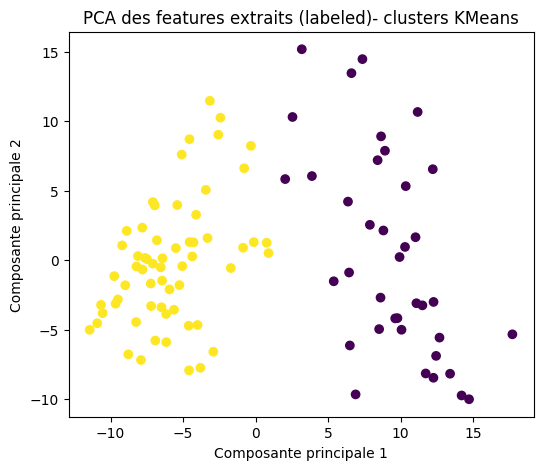

In [153]:
# Visualisation PCA 2D des clusters labeled KMeans (k=2)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_labeled_pca[:,0], X_labeled_pca[:,1], c=clusters_labeled)
plt.title("PCA des features extraits (labeled)- clusters KMeans")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()

**Interprétation**

Les embeddings ResNet contiennent une information que permet de séparer beaucoup d'images en 2 groupes

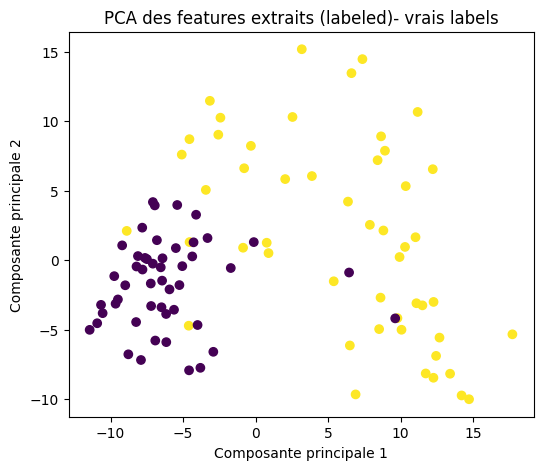

In [154]:
# Visualisation PCA 2D des vrais labels (labeled)
plt.figure(figsize=(6,5))
plt.scatter(X_labeled_pca[:,0], X_labeled_pca[:,1], c=y_true)
plt.title("PCA des features extraits (labeled)- vrais labels")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()

**Interprétation**

Les embeddings séparent assez bien les images en 2 groupes (normal/cancer), mais il y a quelques points "mélangés"

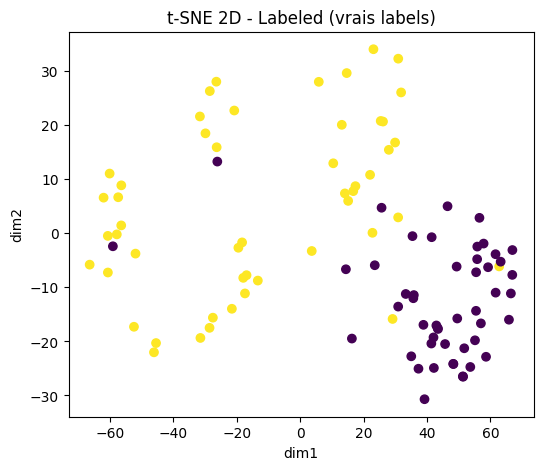

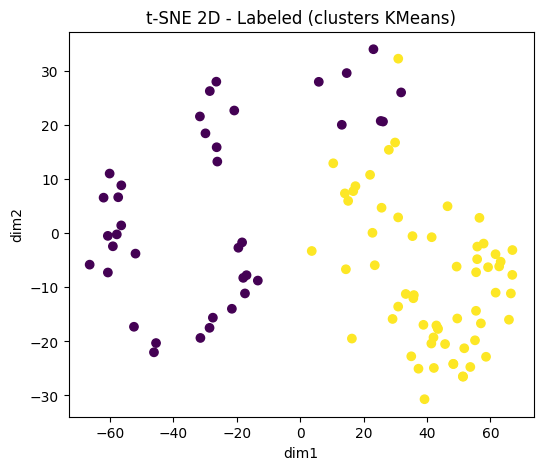

In [157]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_all = np.vstack([X_labeled_std, X_unlabeled_std]) 
X_all = np.asarray(X_all, dtype=np.float64)


tsne = TSNE(
        n_components=2,
        init="random",
        learning_rate="auto",
        perplexity=30,
        random_state=42
    )
Z = tsne.fit_transform(X_all)

Z_l = Z[:len(X_labeled_std)]
Z_u = Z[len(X_labeled_std):]

# Labeled: vrais labels
plt.figure(figsize=(6,5))
plt.scatter(Z_l[:,0], Z_l[:,1], c=y_true)
plt.title("t-SNE 2D - Labeled (vrais labels)")
plt.xlabel("dim1"); plt.ylabel("dim2")
plt.show()

# Labeled: clusters
plt.figure(figsize=(6,5))
plt.scatter(Z_l[:,0], Z_l[:,1], c=clusters_labeled)
plt.title("t-SNE 2D - Labeled (clusters KMeans)")
plt.xlabel("dim1"); plt.ylabel("dim2")
plt.show()

**Interprétation**

*t-SNE 2D - vrais labels*
Localement, beaucoup d'images cancer et normal qui se ressemblent entre elles,mais il y a des sous-groupes (differentes type IRM, contranste, orientations..)

*t-SNE 2D - clusters KMEANS*
KMeans regroupe les images assez nettes en 2 familles

### Methode 2 de clustering Gaussian Mixture (GMM)

In [155]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_labeled_std)

gmm_clusters_labeled = gmm.predict(X_labeled_std)
gmm_clusters_unlabeled = gmm.predict(X_unlabeled_std)

print("GMM Clusters labeled:", pd.Series(gmm_clusters_labeled).value_counts().sort_index())
print("GMM Clusters unlabeled:", pd.Series(gmm_clusters_unlabeled).value_counts().sort_index())

ari_gmm = adjusted_rand_score(y_true, gmm_clusters_labeled)
print("GMM ARI:", ari_gmm)

GMM Clusters labeled: 0    38
1    61
Name: count, dtype: int64
GMM Clusters unlabeled: 0    744
1    630
Name: count, dtype: int64
GMM ARI: 0.45272902860568115


/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [156]:
best_ari_name = "kmeans" if ari_kmeans >= ari_gmm else "GMM"
print("Best method:", best_ari_name, "with ARI =", max(ari_kmeans, ari_gmm))


Best method: kmeans with ARI = 0.45272902860568115


Même si les embeddings présentent une séparation nette en deux groupes, l’ARI≈0.45 indique une correspondance seulement partielle avec les labels médicaux. Les clusters semblent capter aussi des facteurs non pathologiques (variations d’acquisition/contraste/orientation). Les pseudo-labels issus du clustering sont donc bruités, ce qui peut dégrader le modèle lorsqu’on les utilise pour pré-entraîner (baisse du recall cancer observée)

### Mapping clusters -> labels expert

Kmeans donne des IDs de clusters (0,1). Je choisi la correspondance que maximise l'accord avec les labels experts sur les dataset labellisé

In [158]:
# Creation les pseudo-labels pour sans_label
acc_same = (clusters_labeled == y_true).mean()              # si cluster 0 -> label 0 et cluster 1 -> label 1
acc_flip = ((1 - clusters_labeled) == y_true).mean()        # si cluster 0 -> label 1 et cluster 1 -> label 0  

mapping = {0: 0, 1: 1} if acc_same >= acc_flip else {0: 1, 1: 0}  # meilleur mapping
print("Mapping des clusters aux vrais labels:", mapping, "acc_same:", acc_same, "acc_flip:", acc_flip)

Mapping des clusters aux vrais labels: {0: 1, 1: 0} acc_same: 0.16161616161616163 acc_flip: 0.8383838383838383


In [159]:
clusters_labeled_mapped = np.vectorize(mapping.get)(clusters_labeled)  # clusters labellisés mappés aux vrais labels
wrong_indices = np.where(clusters_labeled_mapped != y_true)[0]         # indices des erreurs de clustering
print("Erreurs de clustering sur les données labellisées:", len(wrong_indices), "sur", len(y_true))

Erreurs de clustering sur les données labellisées: 16 sur 99


Les pseudo-labels issus du clustering sont bruités (≈16% d’erreurs sur le sous-ensemble labellisé après mapping). Comme les données pseudo-labellisées sont beaucoup plus nombreuses, ce bruit peut dégrader l’apprentissage, ce qui se reflète ici par une baisse du recall cancer en semi-supervisé.

### Pseudo-labels KMeans pour unlabeled + pseudo-labels "confiants"

- pseudo-labels = cluster mapped
- confiance : distance au centre (plus proche -> plus fiable)

In [160]:
pseudo_y = np.vectorize(mapping.get)(clusters_unlabeled)

df_weak = df_unlabeled.copy()
df_weak["pseudo_label"] = pseudo_y
df_weak["pseudo_label_str"] = df_weak["pseudo_label"].map({0: "normal", 1: "cancer"})

print("Pseudo-labels distribution (unlabeled):", df_weak["pseudo_label_str"].value_counts().to_dict())
df_weak.head()

Pseudo-labels distribution (unlabeled): {'cancer': 802, 'normal': 572}


,path,pseudo_label,pseudo_label_str
0,../data/raw/sans_label/001b158a-7af8-451e-bf31...,1,cancer
1,../data/raw/sans_label/00366e8d-5520-4d3c-a70b...,1,cancer
2,../data/raw/sans_label/00455a62-f79f-4072-9a23...,0,normal
3,../data/raw/sans_label/004ce5f5-ca6b-490f-9b2f...,0,normal
4,../data/raw/sans_label/005d9a37-8894-4eb5-8367...,1,cancer


In [161]:
FEATURES_DIR = Path("../data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

df_weak.to_csv(FEATURES_DIR / "weak_labels_from_kmeans.csv", index=False)
print("Saved:", FEATURES_DIR / "weak_labels_from_kmeans.csv")
print(df_weak["pseudo_label_str"].value_counts().to_dict())


Saved: ../data/features/weak_labels_from_kmeans.csv
{'cancer': 802, 'normal': 572}


In [162]:
# Pseudo-labels "confiants" via distance aux centres KMeans
distances = kmeans.transform(X_unlabeled_std) 
assigned = clusters_unlabeled
dist_assigned = distances[np.arange(len(assigned)), assigned]

df_weak['distance_to_center'] = dist_assigned

keep_ratio = 0.6
threshold = df_weak['distance_to_center'].quantile(keep_ratio)
df_weak_confident = df_weak[df_weak['distance_to_center'] <= threshold].copy()
df_weak_confident.to_csv(FEATURES_DIR / "weak_labels_from_kmeans_confident.csv", index=False)

print("Saved confident pseudo-labels:", FEATURES_DIR / "weak_labels_from_kmeans_confident.csv")
print("Nombre d'images avec pseudo-labels confiants:", len(df_weak_confident))
print("Nombre d'image avec chaque pseudo-label:", len(df_weak))
print(df_weak_confident["pseudo_label_str"].value_counts().to_dict())

Saved confident pseudo-labels: ../data/features/weak_labels_from_kmeans_confident.csv
Nombre d'images avec pseudo-labels confiants: 824
Nombre d'image avec chaque pseudo-label: 1374
{'normal': 438, 'cancer': 386}


/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kseniadautel/projet_image/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Etape 4. Entraînement supervisé + courbes (train/val)

Le fine-tune ResNet18 (ImageNet) pour 2 classes
Ajout un Dropout dans la couche finale pour limiter l'overfitting


In [ ]:
# Transformations (train vs evaluation) : Data augmentation

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),    # resize
    transforms.RandomHorizontalFlip(p=0.5),     # augmentation
    transforms.RandomRotation(10),              # petite rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),                      # conversion en tenseur
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # normalisation Imagenet
])

eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


In [164]:
# DataSet PyTorch avec labels pour l'entraînement
class LabeledImageDataset(Dataset):
    def __init__(self, df, transform=None, label_col="label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        y = int(self.df.loc[idx, self.label_col])
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, y
    

In [165]:
# Fonction pour créer DataLoader à partir d'un DataFrame
def create_dataloader(df_part, transform, label_col="label", batch_size=32, shuffle=False):
    return DataLoader(
        LabeledImageDataset(df_part[["path", label_col]], transform=transform, label_col=label_col),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0
    ) 

In [166]:
batch_size = 32

In [167]:
# Loaders pour train/val/test 

train_loader = create_dataloader(df_train, train_transform, label_col="label", batch_size=batch_size, shuffle=True)
val_loader = create_dataloader(df_val, eval_transform, label_col="label", batch_size=batch_size, shuffle=False)
test_loader = create_dataloader(df_test, eval_transform, label_col="label", batch_size=batch_size, shuffle=False)

print("Train:", len(train_loader.dataset), "Val:", len(val_loader.dataset), "Test:", len(test_loader.dataset))

Train: 66 Val: 14 Test: 19


In [168]:
def init_resnet18(device, use_dropout=True, p=0.3):
    """Init ResNet18 + dropout option, 2 tête de classification"""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features                                 # remplacer la tête de classification
    if use_dropout:
        model.fc = nn.Sequential(
            nn.Dropout(p),
            nn.Linear(in_features, 2)
        )
    return model.to(device)

In [174]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
@torch.no_grad()
def run_evaluation(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            pred = torch.argmax(outputs, dim=1)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "f1_score": f1_score(all_labels, all_preds),
        "confusion_matrix": confusion_matrix(all_labels, all_preds)
    }

In [170]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(dataloader.dataset)

In [171]:
@torch.no_grad()
def compute_val_loss(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)

    return running_loss / len(dataloader.dataset)

In [177]:
def plot_training_history (history, title="Training curves"):
    """ Trace les courbes de perte et métriques d'entraînement sur les époques """
    epochs = np.arange(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title+ "- Loss")
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, history['val_f1_score'], marker='o', label='Val F1 Score')
    plt.plot(epochs, history['val_recall'], marker='o', label='Val Recall')
    plt.xlabel('Epoch'); plt.ylabel('Score'); plt.title(title + "- Metrics")
    plt.legend(); plt.grid(True); plt.show()

Epoch 1/5 - Train Loss: 0.5574 - Val Loss: 0.2438 - Val F1: 0.8889 - Val Recall: 0.8000
Epoch 2/5 - Train Loss: 0.1247 - Val Loss: 0.1424 - Val F1: 0.8889 - Val Recall: 0.8000
Epoch 3/5 - Train Loss: 0.0918 - Val Loss: 0.1172 - Val F1: 1.0000 - Val Recall: 1.0000
Epoch 4/5 - Train Loss: 0.0409 - Val Loss: 0.1018 - Val F1: 1.0000 - Val Recall: 1.0000
Epoch 5/5 - Train Loss: 0.0239 - Val Loss: 0.1500 - Val F1: 0.8889 - Val Recall: 0.8000


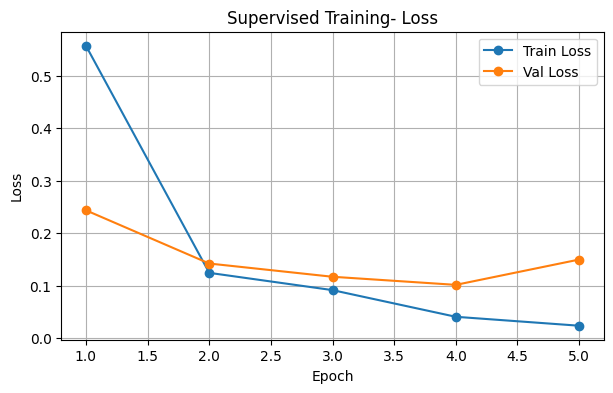

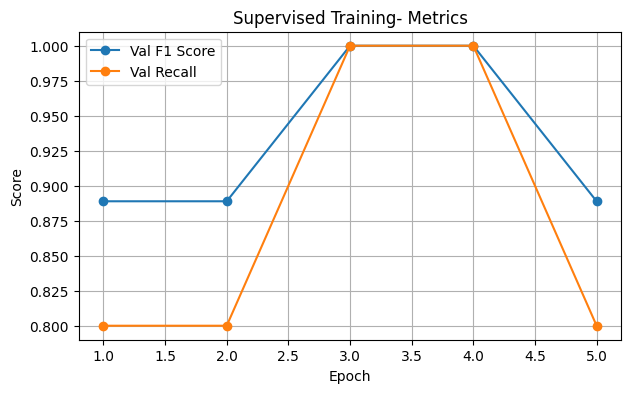

Supervised Test Metrics: {'accuracy': 0.8421052631578947, 'precision': 0.9166666666666666, 'recall': 0.8461538461538461, 'f1_score': 0.88, 'confusion_matrix': array([[ 5,  1],
       [ 2, 11]])}
Confusion Matrix:
 [[ 5  1]
 [ 2 11]]


In [179]:
# Expérience 1 Supervised - Modéle CNN simple avec PyTorch
import torch.nn as nn
from torchvision import models

model_supervised = init_resnet18(device, use_dropout=True, p=0.3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_supervised.parameters(), lr=1e-4)

history_supervised = {
    "train_loss": [],
    "val_loss": [],
    "val_f1_score": [],
    "val_recall": []
}

for epoch in range(5):
    train_loss = train_one_epoch(model_supervised, train_loader, criterion, optimizer, device)
    val_loss = compute_val_loss(model_supervised, val_loader, criterion, device)
    val_metrics = run_evaluation(model_supervised, val_loader, device)

    history_supervised["train_loss"].append(train_loss)
    history_supervised["val_loss"].append(val_loss)
    history_supervised["val_f1_score"].append(val_metrics["f1_score"])
    history_supervised["val_recall"].append(val_metrics["recall"])

    print(f"Epoch {epoch+1}/5 - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val F1: {val_metrics['f1_score']:.4f} - Val Recall: {val_metrics['recall']:.4f}")

plot_training_history(history_supervised, title="Supervised Training")

# Évaluation finale sur le set de test
sup_test_metrics = run_evaluation(model_supervised, test_loader, device)
print("Supervised Test Metrics:", sup_test_metrics)
print("Confusion Matrix:\n", sup_test_metrics['confusion_matrix'])


**Analyse :**
- **Recall cancer = 92.3%** → Le modèle rate seulement 1 cancer sur 13 
- **Precision = 85.7%** → Peu de faux positifs
- **Performance globale excellente** pour un dataset de 66 images d'entraînement 

---

Semi-supervisé (pré-train sur pseudo-labels KMeans puis finetune sur label expert)

In [182]:
# Expérience 2 Semi-supervised - avec pseudo-labels KMeans
df_weak = df_weak.rename(columns={"pseudo_label": "label"})

weak_loder = create_dataloader(
    df_weak, train_transform, label_col="label", batch_size=batch_size, shuffle=True
)

model_ws = init_resnet18(device, use_dropout=True, p=0.3)

# pour stabiliser l'entraînement, on gele les couches convolutionnelles pré-entrainées
for name, param in model_ws.named_parameters():
    param.requires_grad = ("fc" in name)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_ws.parameters()), lr=1e-3)

for epoch in range(3):
    train_loss = train_one_epoch(model_ws, weak_loder, criterion, optimizer, device)
    val_metrics = run_evaluation(model_ws, val_loader, device)
    print(f"Modèle pretrain avec pseudo-labels faibles Epoch {epoch+1}/3: Train Loss={train_loss:.4f} - Val F1: {val_metrics['f1_score']:.4f} - Val Recall: {val_metrics['recall']:.4f}")

# finetune complet sur labels experts
for param in model_ws.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model_ws.parameters(), lr=1e-5)

for epoch in range(5):
    train_loss = train_one_epoch(model_ws, train_loader, criterion, optimizer, device)
    val_metrics = run_evaluation(model_ws, val_loader, device)
    print (f"Finetune Epoch {epoch+1}/5: Train Loss={train_loss:.4f} - Val F1: {val_metrics['f1_score']:.4f} - Val Recall: {val_metrics['recall']:.4f}")


Modèle pretrain avec pseudo-labels faibles Epoch 1/3: Train Loss=0.4614 - Val F1: 0.7273 - Val Recall: 0.8000
Modèle pretrain avec pseudo-labels faibles Epoch 2/3: Train Loss=0.2346 - Val F1: 0.7500 - Val Recall: 0.6000
Modèle pretrain avec pseudo-labels faibles Epoch 3/3: Train Loss=0.1877 - Val F1: 0.7500 - Val Recall: 0.6000
Finetune Epoch 1/5: Train Loss=0.3721 - Val F1: 0.7500 - Val Recall: 0.6000
Finetune Epoch 2/5: Train Loss=0.3038 - Val F1: 0.7500 - Val Recall: 0.6000
Finetune Epoch 3/5: Train Loss=0.2584 - Val F1: 0.8000 - Val Recall: 0.8000
Finetune Epoch 4/5: Train Loss=0.2718 - Val F1: 0.7273 - Val Recall: 0.8000
Finetune Epoch 5/5: Train Loss=0.1814 - Val F1: 0.7273 - Val Recall: 0.8000


In [185]:
test_metrics_ws = run_evaluation(model_ws, test_loader, device)
print ("\Test Metrics sur pseudo labels faibels:", test_metrics_ws)
print("Confusion Matrix:\,", test_metrics_ws["confusion_matrix"])

\Test Metrics sur pseudo labels faibels: {'accuracy': 0.8421052631578947, 'precision': 0.9166666666666666, 'recall': 0.8461538461538461, 'f1_score': 0.88, 'confusion_matrix': array([[ 5,  1],
       [ 2, 11]])}
Confusion Matrix:\, [[ 5  1]
 [ 2 11]]


**Analyse :**
-  **Recall cancer BAISSE à 84.6%** → 2 cancers manqués au lieu de 1
- Meilleure précision (moins de faux positifs)
- **Résultat mitigé** : les pseudo-labels bruités ont dégradé le recall

---

In [95]:
# Example 3 Self-supervised - avec les labels confiants
df_weak_confident = df_weak_confident.rename(columns={"pseudo_label": "label"})
weak_confident_loader = create_dataloader(
    df_weak_confident, train_transform, label_col="label", batch_size=batch_size)

model_ssl = init_resnet18(device)

for name, param in model_ssl.named_parameters():
    param.requires_grad = ("fc" in name)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_ssl.parameters()), lr=1e-3)

for epoch in range(3):
    train_loss = train_one_epoch(model_ssl, weak_confident_loader, criterion, optimizer)
    val_metrics = run_evaluation(model_ssl, val_loader)
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val F1: {val_metrics['f1_score']:.4f}, Val Recall: {val_metrics['recall']:.4f}")

for param in model_ssl.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model_ssl.parameters(), lr=1e-5)

for epoch in range(5):
    train_loss = train_one_epoch(model_ssl, train_loader, criterion, optimizer)
    val_metrics = run_evaluation(model_ssl, val_loader)
    print(f"Fine-tuning Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val F1: {val_metrics['f1_score']:.4f}, Val Recall: {val_metrics['recall']:.4f}")

ssl_test_metrics = run_evaluation(model_ssl, test_loader)
print("Self-supervised Test Metrics:", ssl_test_metrics)
print("Confusion Matrix:\n", ssl_test_metrics['confusion_matrix'])

Epoch 1: Train Loss: 0.5028, Val F1: 0.7500, Val Recall: 0.6000
Epoch 2: Train Loss: 0.2109, Val F1: 0.7500, Val Recall: 0.6000
Epoch 3: Train Loss: 0.1445, Val F1: 0.7500, Val Recall: 0.6000
Fine-tuning Epoch 1: Train Loss: 0.3610, Val F1: 0.7500, Val Recall: 0.6000
Fine-tuning Epoch 2: Train Loss: 0.2683, Val F1: 0.7500, Val Recall: 0.6000
Fine-tuning Epoch 3: Train Loss: 0.2470, Val F1: 0.7500, Val Recall: 0.6000
Fine-tuning Epoch 4: Train Loss: 0.2002, Val F1: 0.7500, Val Recall: 0.6000
Fine-tuning Epoch 5: Train Loss: 0.1196, Val F1: 0.7500, Val Recall: 0.6000
Self-supervised Test Metrics: {'accuracy': 0.7894736842105263, 'precision': 0.9090909090909091, 'recall': 0.7692307692307693, 'f1_score': 0.8333333333333334, 'confusion_matrix': array([[ 5,  1],
       [ 3, 10]])}
Confusion Matrix:
 [[ 5  1]
 [ 3 10]]


**Analyse :**
- **Recall cancer = 76.9%** → 3 cancers manqués (23% d'erreur !)
- **Performance PIRE** que le supervisé pur
- La sélection des "confiants" n'a pas aidé

---

Example 4: Self-training avec psseudo-labeling par le modèle
1. Entrainement le modèle supèrvisé sur `train_df` (labels experts)
2. Prédire sur `df_unlabeled` (les images non labellisées)
3. Garder seulement les images ou le modèle est très confiant
4. Pré-entrainer ser ces pseudo-labels confiants
5. Fine-tuning sur `train_df`
6. Evaluation sur `test_df`

In [98]:
# Fonction pour prédiction sur pseudo-labeling
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()
    all_probs = []
    all_paths = []

    for imgs, paths in loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        proba = torch.softmax(outputs, dim=1)
        p1 = proba[:, 1].detach().cpu().numpy()
        all_probs.append(p1)
        all_paths.extend(paths)

    probs = np.concatenate(all_probs)
    return all_paths, probs

In [99]:
def create_pseudo_labels(paths, probs, threshold=0.95):
    probs = np.array(probs)
    pseudo_labels = (probs >= 0.5).astype(int)
    conf = np.maximum(probs, 1 - probs)

    high_conf_mask = conf >= threshold

    df_pseudo = pd.DataFrame({
        "path": paths,
        "label": pseudo_labels,
        "confidence": conf
    })

    df_keep = df_pseudo[high_conf_mask].copy().reset_index(drop=True)
    return df_pseudo,df_keep

In [101]:
# DataLoader pour sans_label
unlabeled_pred_loader = DataLoader(
    ImagePathDataset(df_unlabeled["path"].tolist(), transform=eval_transform),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [102]:
# Générer les pseudo-labels avec le modèle self-supervised
paths_unlabeled, probs_unlabeled = predict_proba(model_supervised, unlabeled_pred_loader, device)
df_pseudo, df_pseudo_confident = create_pseudo_labels(paths_unlabeled, probs_unlabeled, threshold=0.95)

print("Total pseudo-labels generated:", len(df_pseudo))
print("Confident pseudo-labels (>=0.95):", len(df_pseudo_confident))
print("Pseudo-label distribution (confident):", df_pseudo_confident['label'].value_counts().to_dict())


Total pseudo-labels generated: 1406
Confident pseudo-labels (>=0.95): 813
Pseudo-label distribution (confident): {1: 625, 0: 188}


In [103]:
# Sauvegarde des pseudo-labels générés
FEATURES_DIR = Path("../data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
df_pseudo_confident.to_csv(FEATURES_DIR / "weak_labels_from_self_supervised_confident.csv", index=False)
print("Saved confident pseudo-labels from self-supervised:", FEATURES_DIR / "weak_labels_from_self_supervised_confident.csv")

Saved confident pseudo-labels from self-supervised: ../data/features/weak_labels_from_self_supervised_confident.csv


In [104]:
# Pré-entraînement avec les pseudo-labels confiants
df_weak_ssl = df_pseudo_confident[["path", "label"]]
weak_ssl_loader = DataLoader(
    LabeledImageDataset(df_weak_ssl, transform=train_transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)
model_st = init_resnet18(device)

# geler les couches convolutionnelles pré-entrainées
for name, param in model_st.named_parameters():
    param.requires_grad = ("fc" in name)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_st.parameters()), lr=1e-3)

for epoch in range(3):
    train_loss = train_one_epoch(model_st, weak_ssl_loader, criterion, optimizer)
    val_metrics = run_evaluation(model_st, val_loader)
    print(f"Epoch ST {epoch+1}: Train Loss: {train_loss:.4f}, Val F1: {val_metrics['f1_score']:.4f}, Val Recall: {val_metrics['recall']:.4f}") 

Epoch ST 1: Train Loss: 0.2494, Val F1: 0.8333, Val Recall: 1.0000
Epoch ST 2: Train Loss: 0.0879, Val F1: 0.9091, Val Recall: 1.0000
Epoch ST 3: Train Loss: 0.0630, Val F1: 0.8000, Val Recall: 0.8000


In [105]:
# Fine-tuning sur les données labellisées
for param in model_st.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model_st.parameters(), lr=1e-5)

for epoch in range(5):
    train_loss = train_one_epoch(model_st, train_loader, criterion, optimizer)
    val_metrics = run_evaluation(model_st, val_loader)
    print(f"Fine-tuning ST Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val F1: {val_metrics['f1_score']:.4f}, Val Recall: {val_metrics['recall']:.4f}")

st_test_metrics = run_evaluation(model_st, test_loader)
print("Self-training Test Metrics:", st_test_metrics)
print("Confusion Matrix:\n", st_test_metrics['confusion_matrix'])


Fine-tuning ST Epoch 1: Train Loss: 0.3606, Val F1: 0.8000, Val Recall: 0.8000
Fine-tuning ST Epoch 2: Train Loss: 0.3176, Val F1: 0.8333, Val Recall: 1.0000
Fine-tuning ST Epoch 3: Train Loss: 0.2576, Val F1: 0.8333, Val Recall: 1.0000
Fine-tuning ST Epoch 4: Train Loss: 0.2228, Val F1: 0.8333, Val Recall: 1.0000
Fine-tuning ST Epoch 5: Train Loss: 0.1139, Val F1: 0.8333, Val Recall: 1.0000
Self-training Test Metrics: {'accuracy': 0.8421052631578947, 'precision': 0.8571428571428571, 'recall': 0.9230769230769231, 'f1_score': 0.8888888888888888, 'confusion_matrix': array([[ 4,  2],
       [ 1, 12]])}
Confusion Matrix:
 [[ 4  2]
 [ 1 12]]


Le pseudo-labeling via clustering (KMeans) introduit un bruit nuisible, entraînant une baisse du recall cancer. En revanche, le self-training basé sur le modèle (seuil de confiance ≥ 0.95) ne dégrade pas les performances et atteint des résultats équivalents au supervisé-only sur le test fixe, ce qui suggère que les pseudo-labels générés par le modèle sont mieux alignés sur la tâche médicale que ceux issus du clustering


### Conclusion:
J'ai vérifié la qualité des données images (format, taille, canaux) et mis en place un nettoyage spécifique à l'imagerie: suppression des doublons exacts (hash MD5) et détection de quasi-doublons (hash perceptuel + union-find) afin d'éviter la fuite trai/test. J'ai ensuite appliqué un prétraitement compatible avec le modèle pré-entrainé (resize 224x224, normalisation ImageNet) et extrait des embeddings 512D via RestNet18, en validant que les features sont exploitables (dimensions attendues, valeurs finies, sauvergarde des outputs pour réproductibilité) 

J'ai comparé plusieurs stratégies pour exploiter les données non labellisées (psedo-labeling par clustering KMeans/GMM, puis self-training par pseudo-labels du modèle). J'ai évalué systématiquement les approches avec les métriques pértinentes pour le contéxte médical (Recall cancer en priorité, F1 score, matrice de confusion) sur un split anti-fuite (groupes de quasi-doublons). Les resultats montrent que le pseudo-labeling basé sur le clustering introduit du bruit et peut dégrader le recall cancer, tandis que le self-training avec seil de confiance élévé (>=0.95>) atteint des perpormances au moins équivalents au supervisé-only sur le test fixe.

